# Benchmark Analysis

This notebook uses the benchmark analysis API from `examples/benchmark_runner.py` to:

1. load a full benchmark session
2. group runs by restart family and select the top `K` groups by minimal `best_loss`
3. plot aggregate loss lines for the selected subset
4. load the best model from each selected restart group and scatter plot samples


In [1]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

from benchmark_runner import (
    entries_to_frame,
    entry_arrays,
    get_lines,
    import_runtime_dependencies,
    load_entry_model,
    load_experiment_entries,
    restart_group_columns,
)


In [2]:
session_dir = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260713_015658/')
entries = load_experiment_entries(session_dir)
# session_dir = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260708_203116/')
# entries += load_experiment_entries(session_dir)
df_all = entries_to_frame(entries)
df_all.columns

Index(['entry_index', 'run_id', 'run_dir', 'checkpoint_best',
       'checkpoint_last', 'best_loss', 'best_iteration', 'final_loss',
       'method', 'restart_index', 'method_kwargs.max_iterations',
       'method_kwargs.batch_size', 'method_kwargs.N_monte_carlo',
       'method_kwargs.master_seed', 'method_kwargs.eval_every',
       'method_kwargs.linear_solver_tolerance',
       'method_kwargs.natural_grad_clipping_threshold',
       'method_kwargs.step_size', 'method_kwargs.linear_solver_regularization',
       'architecture.rhs.model', 'architecture.rhs.activation',
       'architecture.rhs.dim_hidden', 'architecture.rhs.n_hidden',
       'architecture.divergence_method', 'architecture.ode_nstep_max',
       'architecture.ode_method', 'architecture.adaptive',
       'architecture.h_max', 'problem.functional.kind',
       'problem.distribution.name', 'problem.distribution.resample_each',
       'problem.distribution.seed'],
      dtype='str')

In [4]:
arch_cols = [colname for colname in df_all.columns if 'architecture' in colname]

cmaps = ['Reds', 'Blues', 'Oranges']

for arch_param, df_arch in df_all.groupby(arch_cols):
    _, _, w_hidden, n_hidden, _, n_steps, _, _, _ = arch_param
    group_cols = restart_group_columns(df_arch)
    best_k_with_reruns = df_arch.\
        groupby(group_cols).\
        apply(lambda _df: _df['best_loss'].min(), include_groups=False)
        

In [5]:
def select_top_k_restart_groups(entries, k):
    frame = entries_to_frame(entries)
    # frame = frame.query('`architecture.rhs.n_hidden` == 1 and best_loss > best_loss.quantile(0.02)')
    # frame = frame.query('`architecture.rhs.n_hidden` == 1 and `architecture.rhs.dim_hidden` == 16 and best_loss > best_loss.quantile(0.02)')
    group_cols = restart_group_columns(frame)

    if not group_cols:
        summary = frame[['entry_index', 'best_loss']].copy()
        summary['group_rank'] = 0
        return entries, summary

    summary = (
        frame.groupby(group_cols, sort=False, dropna=False, as_index=False)
        .agg(
            final_loss=('final_loss', 'mean'),
            n_restarts=('entry_index', 'count'),
        )
        .sort_values('final_loss', ascending=True, kind='stable')
        .head(k)
        # .reset_index(drop=True)
    )
    summary['group_rank'] = np.arange(len(summary))

    selected_frame = frame.merge(summary[group_cols], on=group_cols, how='inner')
    selected_indices = selected_frame['entry_index'].tolist()
    subset_entries = [entries[index] for index in selected_indices]
    return subset_entries, summary


def best_entry_per_restart_group(entries):
    frame = entries_to_frame(entries)
    group_cols = restart_group_columns(frame)

    if not group_cols:
        if not entries:
            return []
        best_index = int(frame['best_loss'].idxmin())
        return [entries[int(frame.loc[best_index, 'entry_index'])]]

    best_row_indices = (
        frame.groupby(group_cols, sort=False, dropna=False)['best_loss']
        .idxmin()
        .tolist()
    )
    entry_indices = frame.loc[best_row_indices, 'entry_index'].tolist()
    return [entries[int(index)] for index in entry_indices]


In [6]:
top_k = 25
subset_entries, subset_summary = select_top_k_restart_groups(entries, top_k)
best_entries = best_entry_per_restart_group(subset_entries)

print(f'selected {len(subset_entries)} entries across {len(best_entries)} restart groups')



selected 150 entries across 25 restart groups


In [7]:
def plot_line_groups(groups):
    for group in groups:
        fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')

        for line in group['lines']:
            style = line.get('style', {})
            color = style.get('color')
            linestyle = style.get('linestyle', '-')
            linewidth = style.get('linewidth', 1.5)

            if 'loss_mean' in line:
                x = np.arange(len(line['loss_mean']))
                ax.plot(
                    x,
                    line['loss_mean'],
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )
                if 'loss_lower' in line and 'loss_upper' in line:
                    ax.fill_between(
                        x,
                        line['loss_lower'],
                        line['loss_upper'],
                        color=color,
                        alpha=0.2,
                    )
            else:
                loss = np.asarray(line['loss'], dtype=float)
                x = np.arange(len(loss))
                ax.plot(
                    x,
                    loss,
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )

        ax.set_title(group['title'])
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_ylim(
            bottom=subset_summary['final_loss'].min(),
            top=line['loss_upper'][0], )
        ax.grid()
        fig.legend(loc='outside lower center')
        plt.show()


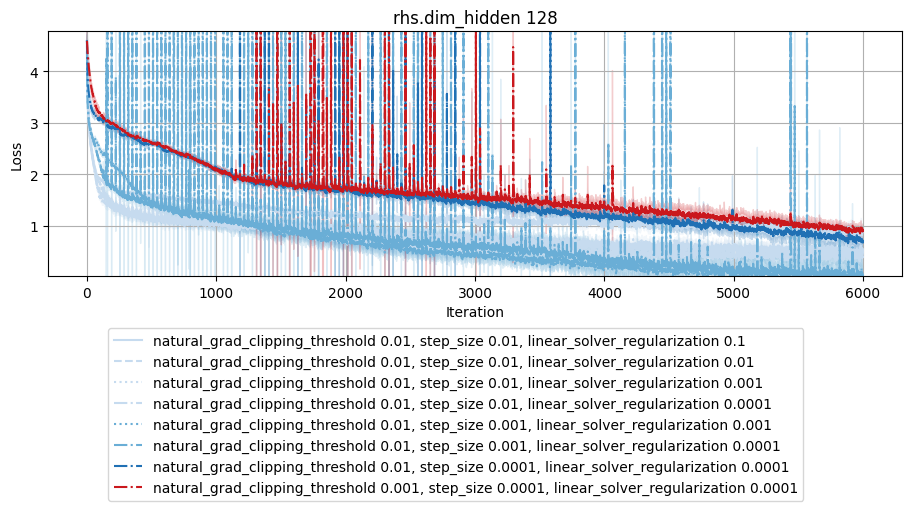

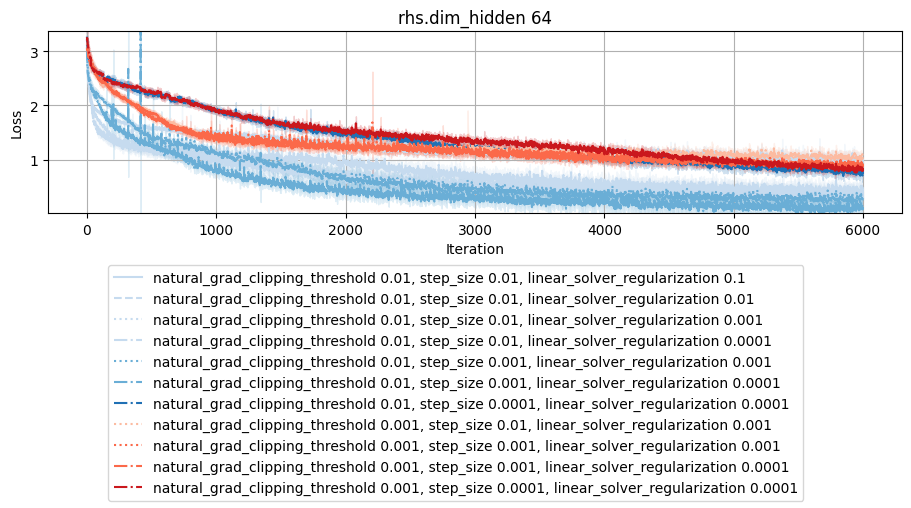

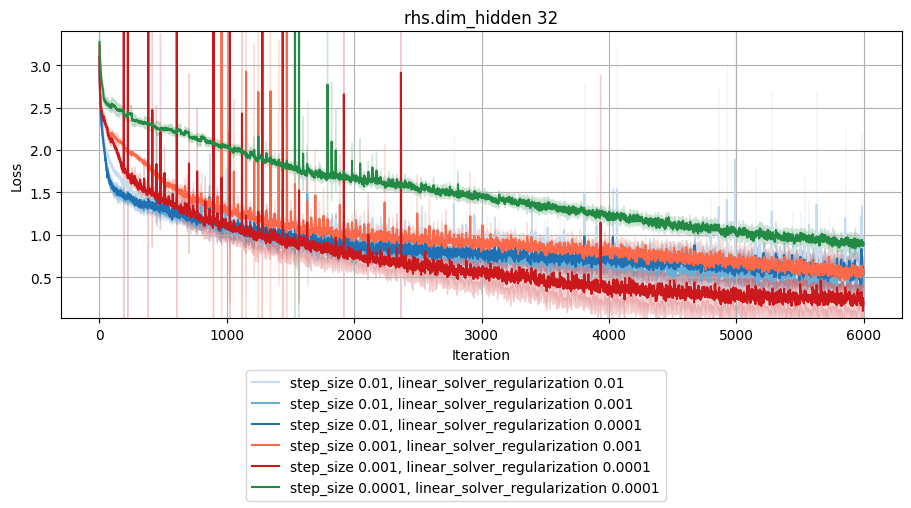

In [8]:
style_channels = {
    'colormap': ['Blues', 'Reds', 'Greens', 'Purples'],
    'linestyle': ['-', '--', ':', '-.'],
}

groups = get_lines(subset_entries, style_channels)
plot_line_groups(groups)


In [21]:
def scatter_best_entries(entries, checkpoint_key='best', n_samples=512):
    if not entries:
        return

    deps = import_runtime_dependencies()
    ncols = min(3, len(entries))
    nrows = int(np.ceil(len(entries) / ncols))
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * nrows),
        layout='constrained',
    )
    axs = np.atleast_1d(axs).ravel()

    for ax, entry in zip(axs, entries, strict=False):
        model = load_entry_model(entry, key=checkpoint_key)
        samples = model.sample(n_samples, deps['nnx'].Rngs(0))

        if samples.shape[-1] >= 2:
            ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.7)
            ax.set_xlabel('x[0]')
            ax.set_ylabel('x[1]')
        else:
            ax.hist(samples[:, 0], bins=40)

        ax.set_title(
            f"{entry['run_id']} d_hidden {entry['architecture']['rhs']['dim_hidden']} r{entry['restart_index']}\n"
            f"best_loss={entry.get('best_loss', np.nan):.3e}, iter={entry.get('best_iteration')}"
        )
        ax.grid()

    for ax in axs[len(entries):]:
        ax.axis('off')

    plt.show()


In [22]:
bes = sorted(best_entries, key=lambda _e: _e['best_loss'])

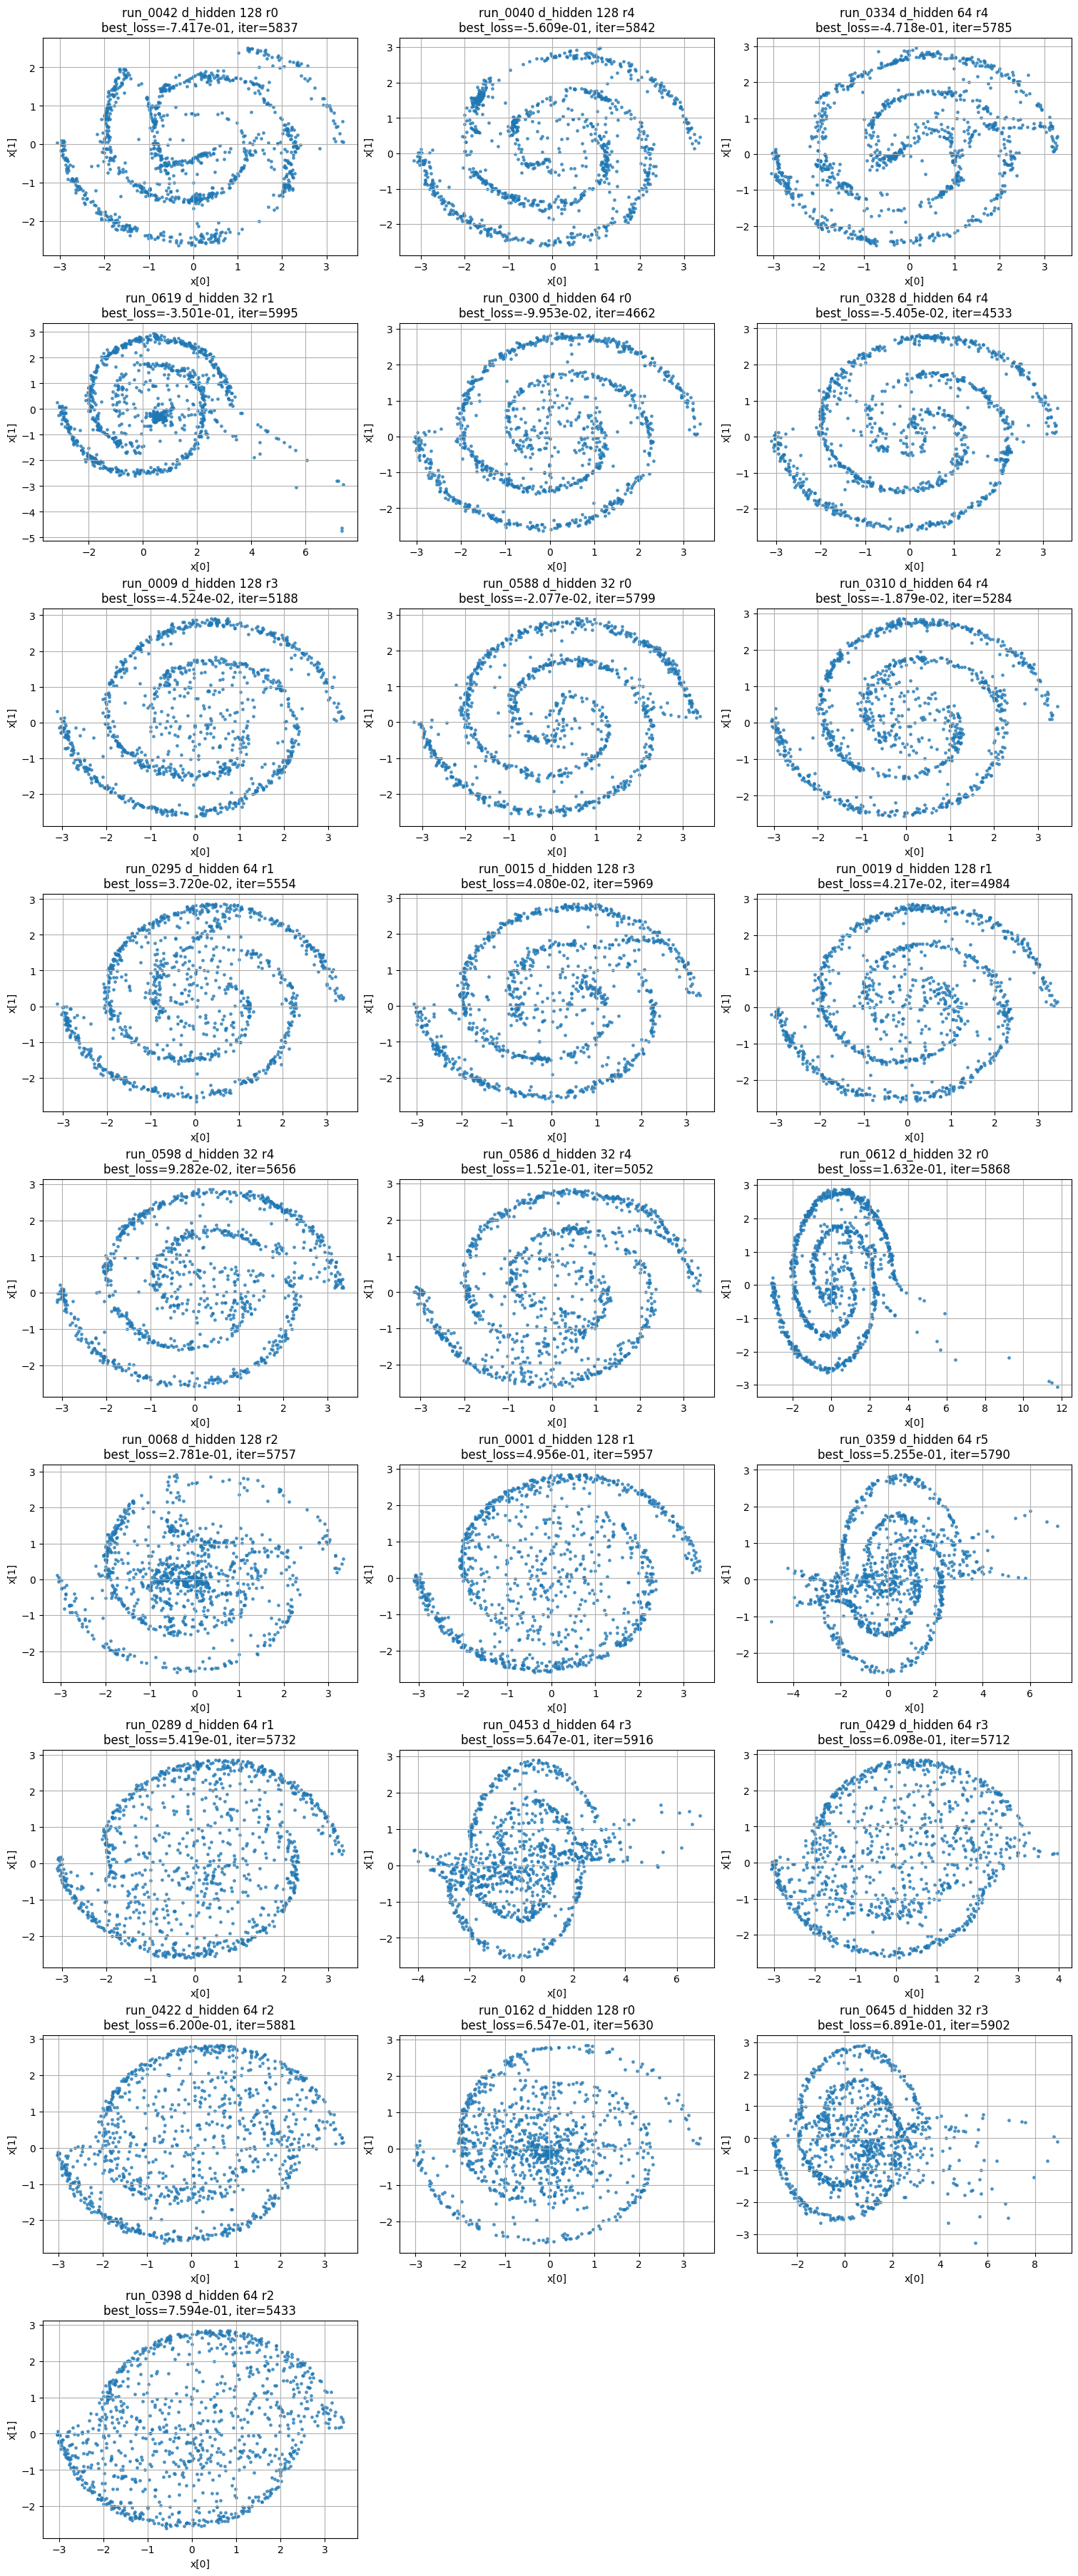

In [23]:
scatter_best_entries(bes, checkpoint_key='best', n_samples=1024)

In [15]:
best_entries[-3]

{'run_index': 612,
 'run_id': 'run_0612',
 'restart_index': 0,
 'problem': {'functional': {'kind': 'CrossEntropy'},
  'distribution': {'name': 'two_spirals', 'resample_each': 32, 'seed': 3}},
 'resolved_problem': {'dim': 2,
  'dim_source': 'data',
  'distribution_name': 'two_spirals'},
 'architecture': {'rhs': {'model': 'MLP',
   'activation': 'swish',
   'dim_hidden': 32,
   'n_hidden': 1},
  'divergence_method': 'hutchinson',
  'ode_nstep_max': 6,
  'ode_method': 'rk45',
  'adaptive': 'true',
  'h_max': 0.3},
 'method': 'ngd',
 'method_kwargs': {'max_iterations': 6000,
  'batch_size': 512,
  'N_monte_carlo': 512,
  'master_seed': 42,
  'eval_every': 600,
  'linear_solver_tolerance': 1e-06,
  'natural_grad_clipping_threshold': 0.01,
  'step_size': 0.001,
  'linear_solver_regularization': 0.001},
 'run_dir': PosixPath('results/ce_two_spirals_arch_search_clipping/benchmark_20260713_015658/runs/run_0612'),
 'checkpoints': {'best': PosixPath('/Home/optimier/aksenov/Documents/code/NeuRiPP/

In [ ]:
df_all = entries_to_frame(entries)

In [ ]:
df_all.columns

In [ ]:
restart_group_columns(df_all)